## The notebook copied from scikit learn, with some modifications

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn import datasets, model_selection, tree

In [2]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, random_state=0
)

clf = tree.DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [13]:
n_nodes = clf.tree_.node_count
children_left = clf.tree_.children_left
children_right = clf.tree_.children_right
feature = clf.tree_.feature
threshold = clf.tree_.threshold
values = clf.tree_.value

{
    'n_nodes': n_nodes,
    'children_left': children_left,
    'children_right': children_right,
    'feature': feature,
    'threshold': threshold,
    'values': values,
}

{'n_nodes': 13,
 'children_left': array([ 1, -1,  3,  4, -1,  6, -1, -1,  9, 10, -1, -1, -1], dtype=int64),
 'children_right': array([ 2, -1,  8,  5, -1,  7, -1, -1, 12, 11, -1, -1, -1], dtype=int64),
 'feature': array([ 3, -2,  2,  3, -2,  1, -2, -2,  3,  3, -2, -2, -2], dtype=int64),
 'threshold': array([ 0.80000001, -2.        ,  4.95000005,  1.65000004, -2.        ,
         3.10000002, -2.        , -2.        ,  1.75      ,  1.65000004,
        -2.        , -2.        , -2.        ]),
 'values': array([[[0.33035714, 0.30357143, 0.36607143]],
 
        [[1.        , 0.        , 0.        ]],
 
        [[0.        , 0.45333333, 0.54666667]],
 
        [[0.        , 0.91666667, 0.08333333]],
 
        [[0.        , 1.        , 0.        ]],
 
        [[0.        , 0.25      , 0.75      ]],
 
        [[0.        , 0.        , 1.        ]],
 
        [[0.        , 1.        , 0.        ]],
 
        [[0.        , 0.02564103, 0.97435897]],
 
        [[0.        , 0.25      , 0.75      ]

In [4]:
node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)
stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
while len(stack) > 0:
    # `pop` ensures each node is only visited once
    node_id, depth = stack.pop()
    node_depth[node_id] = depth

    # If the left and right child of a node is not the same we have a split
    # node
    is_split_node = children_left[node_id] != children_right[node_id]
    # If a split node, append left and right children and depth to `stack`
    # so we can loop through them
    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
    else:
        is_leaves[node_id] = True

print(
    "The binary tree structure has {n} nodes and has "
    "the following tree structure:\n".format(n=n_nodes)
)
for i in range(n_nodes):
    if is_leaves[i]:
        print(
            "{space}node={node} is a leaf node with value={value}.".format(
                space=node_depth[i] * "\t", node=i, value=np.around(values[i], 3)
            )
        )
    else:
        print(
            "{space}node={node} is a split node with value={value}: "
            "go to node {left} if X[:, {feature}] <= {threshold} "
            "else to node {right}.".format(
                space=node_depth[i] * "\t",
                node=i,
                left=children_left[i],
                feature=feature[i],
                threshold=threshold[i],
                right=children_right[i],
                value=np.around(values[i], 3),
            )
        )

The binary tree structure has 13 nodes and has the following tree structure:

node=0 is a split node with value=[[0.33  0.304 0.366]]: go to node 1 if X[:, 3] <= 0.800000011920929 else to node 2.
	node=1 is a leaf node with value=[[1. 0. 0.]].
	node=2 is a split node with value=[[0.    0.453 0.547]]: go to node 3 if X[:, 2] <= 4.950000047683716 else to node 8.
		node=3 is a split node with value=[[0.    0.917 0.083]]: go to node 4 if X[:, 3] <= 1.6500000357627869 else to node 5.
			node=4 is a leaf node with value=[[0. 1. 0.]].
			node=5 is a split node with value=[[0.   0.25 0.75]]: go to node 6 if X[:, 1] <= 3.100000023841858 else to node 7.
				node=6 is a leaf node with value=[[0. 0. 1.]].
				node=7 is a leaf node with value=[[0. 1. 0.]].
		node=8 is a split node with value=[[0.    0.026 0.974]]: go to node 9 if X[:, 3] <= 1.75 else to node 12.
			node=9 is a split node with value=[[0.   0.25 0.75]]: go to node 10 if X[:, 3] <= 1.6500000357627869 else to node 11.
				node=10 is a 

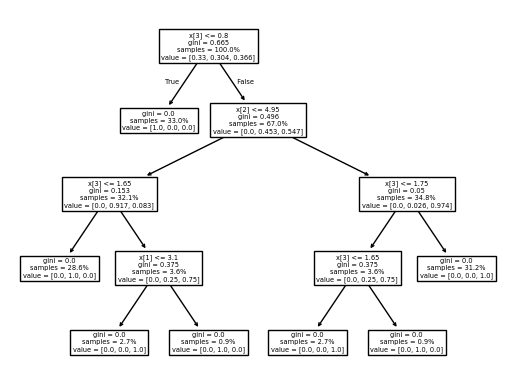

In [5]:
tree.plot_tree(clf, proportion=True)
plt.show()

In [12]:
threshold

array([ 0.80000001, -2.        ,  4.95000005,  1.65000004, -2.        ,
        3.10000002, -2.        , -2.        ,  1.75      ,  1.65000004,
       -2.        , -2.        , -2.        ])

In [6]:
node_indicator = clf.decision_path(X_test)
node_indicator.shape

(38, 13)

In [7]:
leaf_id = clf.apply(X_test)
leaf_id

array([12,  4,  1, 12,  1, 12,  1,  4,  4,  4, 10,  4,  4,  4,  4,  1,  4,
        4,  1,  1,  6,  4,  1,  1,  6,  1,  1,  4,  4,  1, 12,  4,  1,  6,
       12,  4,  1, 10])

In [8]:
sample_id = 0
# obtain ids of the nodes `sample_id` goes through, i.e., row `sample_id`
node_index = node_indicator.indices[
    node_indicator.indptr[sample_id] : node_indicator.indptr[sample_id + 1]
]

print("Rules used to predict sample {id}:\n".format(id=sample_id))
for node_id in node_index:
    # continue to the next node if it is a leaf node
    if leaf_id[sample_id] == node_id:
        continue

    # check if value of the split feature for sample 0 is below threshold
    if X_test[sample_id, feature[node_id]] <= threshold[node_id]:
        threshold_sign = "<="
    else:
        threshold_sign = ">"

    print(
        "decision node {node} : (X_test[{sample}, {feature}] = {value}) "
        "{inequality} {threshold})".format(
            node=node_id,
            sample=sample_id,
            feature=feature[node_id],
            value=X_test[sample_id, feature[node_id]],
            inequality=threshold_sign,
            threshold=threshold[node_id],
        )
    )

Rules used to predict sample 0:

decision node 0 : (X_test[0, 3] = 2.4) > 0.800000011920929)
decision node 2 : (X_test[0, 2] = 5.1) > 4.950000047683716)
decision node 8 : (X_test[0, 3] = 2.4) > 1.75)


In [9]:
print(tree.export_text(clf))

|--- feature_3 <= 0.80
|   |--- class: 0
|--- feature_3 >  0.80
|   |--- feature_2 <= 4.95
|   |   |--- feature_3 <= 1.65
|   |   |   |--- class: 1
|   |   |--- feature_3 >  1.65
|   |   |   |--- feature_1 <= 3.10
|   |   |   |   |--- class: 2
|   |   |   |--- feature_1 >  3.10
|   |   |   |   |--- class: 1
|   |--- feature_2 >  4.95
|   |   |--- feature_3 <= 1.75
|   |   |   |--- feature_3 <= 1.65
|   |   |   |   |--- class: 2
|   |   |   |--- feature_3 >  1.65
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  1.75
|   |   |   |--- class: 2

